In [1]:
# ============================================================
# 03_monte_carlo_model.ipynb — Monte Carlo Simulation
# ============================================================

from __future__ import annotations

import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Locate project root ----------
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR

for _ in range(8):
    if (PROJECT_ROOT / "config.py").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "config.py").exists():
    raise FileNotFoundError("config.py not found")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ---------- Load config ----------
import config
config.ensure_dirs()

# ---------- Reproducibility ----------
SEED = 42
rng = np.random.default_rng(SEED)
N_SIMS = 10_000

# ---------- Load cleaned ground truth ----------
GT_PATH = config.DATA_PROCESSED / "ground_truth_clean.csv"
gt = pd.read_csv(GT_PATH)

base = (
    gt.loc[gt["Scenario"] == "Base"]
    .copy()
    .sort_values("FY")
    .reset_index(drop=True)
)

print("Project root:", PROJECT_ROOT)
print("Ground truth path:", GT_PATH)
print("Base rows:", len(base))
print("FY range:", base["FY"].min(), "-", base["FY"].max())
print("Simulations:", N_SIMS)


Project root: C:\Users\Noah\PG3_Royalty_Python_Model
Ground truth path: C:\Users\Noah\PG3_Royalty_Python_Model\Data\processed\ground_truth_clean.csv
Base rows: 16
FY range: 2024 - 2039
Simulations: 10000


In [2]:
# ============================================================
# Stochastic Inputs (Monte Carlo)
# - Define distributions for uncertain drivers
# - Provide sampling functions (vectorized)
# ============================================================

from dataclasses import dataclass
from typing import Optional, Dict


@dataclass(frozen=True)
class TriangularSpec:
    """
    Triangular distribution specification.
    Parameters:
      - low: minimum possible value
      - mode: most likely value
      - high: maximum possible value
    """
    low: float
    mode: float
    high: float


@dataclass(frozen=True)
class NormalSpec:
    """
    Normal distribution specification.
    Parameters:
      - mu: mean
      - sigma: standard deviation
    """
    mu: float
    sigma: float


@dataclass(frozen=True)
class MCConfig:
    """
    Monte Carlo configuration (stochastic drivers).
    Notes (for thesis):
      - Exit Multiple is typically the dominant value driver in exit-based valuation.
      - Additional uncertainty can be layered on via growth or interest, but start parsimonious.
    """
    n_sims: int
    seed: int

    # Core driver
    exit_multiple: TriangularSpec

    # Optional drivers (activate later)
    revenue_growth_shock: Optional[NormalSpec] = None   # applied as multiplicative shock to cashflows
    interest_rate_shock: Optional[NormalSpec] = None    # only if your engine uses interest explicitly


def sample_triangular(rng: np.random.Generator, spec: TriangularSpec, n: int) -> np.ndarray:
    """Vectorized sampling from triangular distribution."""
    if not (spec.low <= spec.mode <= spec.high):
        raise ValueError("TriangularSpec requires low <= mode <= high.")
    return rng.triangular(left=spec.low, mode=spec.mode, right=spec.high, size=n)


def sample_normal(rng: np.random.Generator, spec: NormalSpec, n: int) -> np.ndarray:
    """Vectorized sampling from normal distribution."""
    if spec.sigma < 0:
        raise ValueError("NormalSpec requires sigma >= 0.")
    return rng.normal(loc=spec.mu, scale=spec.sigma, size=n)


# ----------------------------
# Baseline MC assumptions (EDITABLE)
# ----------------------------
# Thesis-friendly rationale:
# - Use a triangular distribution for Exit Multiple:
#   lower bound reflects stressed exits, mode reflects base case, upper bound reflects optimistic exits.
mc_cfg = MCConfig(
    n_sims=N_SIMS,
    seed=SEED,
    exit_multiple=TriangularSpec(low=8.0, mode=12.0, high=18.0),

    # Keep these OFF initially (None). Switch on after exit-multiple-only model is validated.
    revenue_growth_shock=None,
    interest_rate_shock=None,
)

# ----------------------------
# Draw samples (core driver)
# ----------------------------
exit_mult_samples = sample_triangular(rng, mc_cfg.exit_multiple, mc_cfg.n_sims)

# Quick diagnostics
print("Exit Multiple (triangular) samples")
print("  min / mean / max:", exit_mult_samples.min(), exit_mult_samples.mean(), exit_mult_samples.max())
print("  p5 / p50 / p95 :", np.percentile(exit_mult_samples, [5, 50, 95]))


Exit Multiple (triangular) samples
  min / mean / max: 8.112146269503173 12.647684949877002 17.962868141194555
  p5 / p50 / p95 : [ 9.40103968 12.5134792  16.26800818]


In [3]:
base[["FY", "NAV", "NAV_Multiple", "Equity_Ticket", "Equity_CF"]].tail(5)


,FY,NAV,NAV_Multiple,Equity_Ticket,Equity_CF
11,2035,781.2,12.0,99.4,9.638143
12,2036,789.6,12.0,99.4,9.834580
13,2037,796.8,12.0,99.4,10.002954
14,2038,804.0,12.0,99.4,10.171329
15,2039,810.0,12.0,99.4,100.067590


In [4]:
# ============================================================
# IRR (annual) — robust implementation (bisection on NPV)
# ============================================================

def irr_annual(cashflows, guess=0.1, tol=1e-10, max_iter=200):
    """
    Compute annual IRR for equally spaced annual cashflows using bisection on NPV.

    Parameters
    ----------
    cashflows : array-like
        Cashflows at t=0..T (annual steps)
    guess : float
        Not used for bisection; kept for interface compatibility
    tol : float
        Convergence tolerance for NPV
    max_iter : int
        Max bisection iterations

    Returns
    -------
    irr : float
        Annual IRR (as decimal, e.g. 0.12 for 12%)
    """
    cf = np.asarray(cashflows, dtype=float)

    def npv(r):
        # Avoid division by zero at r = -1
        if r <= -0.999999999:
            return np.inf
        return np.sum(cf / (1.0 + r) ** np.arange(cf.size))

    # We need a bracket [lo, hi] where NPV(lo) and NPV(hi) have opposite signs
    lo, hi = -0.9999, 10.0  # allow extremely high IRRs if TV dominates
    f_lo, f_hi = npv(lo), npv(hi)

    # If no sign change, try expanding upper bound
    expand = 0
    while np.sign(f_lo) == np.sign(f_hi) and expand < 30:
        hi *= 2.0
        f_hi = npv(hi)
        expand += 1

    if np.sign(f_lo) == np.sign(f_hi):
        return np.nan  # IRR not well-defined / no sign change

    for _ in range(max_iter):
        mid = (lo + hi) / 2.0
        f_mid = npv(mid)

        if abs(f_mid) < tol:
            return float(mid)

        if np.sign(f_mid) == np.sign(f_lo):
            lo, f_lo = mid, f_mid
        else:
            hi, f_hi = mid, f_mid

    return float((lo + hi) / 2.0)


In [5]:
def equity_cf_for_irr(base_df: pd.DataFrame, exit_multiple: float) -> np.ndarray:
    """
    Cashflows for IRR:
    - t0: -Equity_Ticket (plus any CF already in first year)
    - years 1..T: Equity_CF
    - exit year: replace ONLY the terminal component with simulated terminal value
    """

    m = base_df.copy().sort_values("FY").reset_index(drop=True)

    entry_idx = 0
    exit_idx = len(m) - 1

    # base series
    cf = m["Equity_CF"].astype(float).to_numpy(copy=True)

    # ---- ENTRY ----
    ticket = float(m.loc[entry_idx, "Equity_Ticket"])
    cf[entry_idx] = cf[entry_idx] - ticket

    # ---- EXIT BASE COMPONENTS ----
    nav_exit_base = float(m.loc[exit_idx, "NAV"])
    debt_exit = float(m.loc[exit_idx, "Debt_End"])
    pg_share = float(m.loc[exit_idx, "PG_Share"])
    mult_base = float(m.loc[exit_idx, "NAV_Multiple"])

    # base equity value (PG share)
    exit_equity_base = (nav_exit_base - debt_exit) * pg_share

    # split exit CF into operating + terminal
    terminal_cf_base = exit_equity_base
    operating_cf_exit = cf[exit_idx] - terminal_cf_base

    # ---- SIMULATED TERMINAL ----
    nav_exit_sim = nav_exit_base * (exit_multiple / mult_base)
    exit_equity_sim = (nav_exit_sim - debt_exit) * pg_share

    # ---- REPLACE ONLY TERMINAL ----
    cf[exit_idx] = operating_cf_exit + exit_equity_sim

    return cf


In [6]:
# --------------------------------------------------
# Single simulation path
# --------------------------------------------------

def run_one_path(base_df, exit_multiple: float):
    """
    Runs one valuation path with a given exit multiple.
    Returns IRR and MOIC.
    """

    # build cashflows with simulated exit
    cf = equity_cf_for_irr(base_df, exit_multiple)

    # IRR
    irr = irr_annual(cf)

    # MOIC (multiple of invested capital)
    invested = -cf[0]          # equity ticket at t0 (negative)
    returned = cf[1:].sum()    # total cash returned
    moic = returned / invested if invested != 0 else np.nan

    return {
        "exit_multiple": exit_multiple,
        "irr": irr,
        "moic": moic
    }

In [7]:
# ============================================================
# Monte Carlo simulation run (Exit Multiple only)
# ============================================================

results = np.empty((mc_cfg.n_sims, 3), dtype=float)  # [Exit_Multiple, IRR, MOIC]

for i, mult in enumerate(exit_mult_samples):
    out = run_one_path(base, exit_multiple=float(mult))
    results[i, 0] = out["exit_multiple"]
    results[i, 1] = out["irr"]
    results[i, 2] = out["moic"]

mc_results = pd.DataFrame(results, columns=["Exit_Multiple", "IRR", "MOIC"])
mc_results = mc_results.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print("MC rows:", len(mc_results))
print("IRR min/max/range:",
      mc_results["IRR"].min(), mc_results["IRR"].max(),
      mc_results["IRR"].max() - mc_results["IRR"].min())



MC rows: 10000
IRR min/max/range: -0.025908267622016104 0.05179571812797294 0.07770398574998905


In [8]:
# ============================================================
# Risk metrics (VaR / CVaR) + summary table
# ============================================================

def var_cvar_left(x: np.ndarray, alpha: float = 0.05) -> tuple[float, float]:
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    var = float(np.quantile(x, alpha))
    cvar = float(x[x <= var].mean()) if np.any(x <= var) else np.nan
    return var, cvar

irr = mc_results["IRR"].to_numpy()
moic = mc_results["MOIC"].to_numpy()

irr_var5, irr_cvar5 = var_cvar_left(irr, 0.05)
moic_var5, moic_cvar5 = var_cvar_left(moic, 0.05)

summary_df = pd.DataFrame([{
    "N_SIMS": int(len(mc_results)),
    "SEED": int(SEED),

    "ExitMult_low": mc_cfg.exit_multiple.low,
    "ExitMult_mode": mc_cfg.exit_multiple.mode,
    "ExitMult_high": mc_cfg.exit_multiple.high,

    "IRR_mean": float(np.mean(irr)),
    "IRR_p5": float(np.quantile(irr, 0.05)),
    "IRR_p50": float(np.quantile(irr, 0.50)),
    "IRR_p95": float(np.quantile(irr, 0.95)),
    "IRR_VaR_5": irr_var5,
    "IRR_CVaR_5": irr_cvar5,

    "MOIC_mean": float(np.mean(moic)),
    "MOIC_p5": float(np.quantile(moic, 0.05)),
    "MOIC_p50": float(np.quantile(moic, 0.50)),
    "MOIC_p95": float(np.quantile(moic, 0.95)),
    "MOIC_VaR_5": moic_var5,
    "MOIC_CVaR_5": moic_cvar5,
}])

summary_df


,N_SIMS,SEED,ExitMult_low,ExitMult_mode,ExitMult_high,IRR_mean,IRR_p5,IRR_p50,IRR_p95,IRR_VaR_5,IRR_CVaR_5,MOIC_mean,MOIC_p5,MOIC_p50,MOIC_p95,MOIC_VaR_5,MOIC_CVaR_5
0,10000,42,8.0,12.0,18.0,0.019656,-0.008219,0.020514,0.043561,-0.008219,-0.014042,1.26016,0.922432,1.246199,1.63676,0.922432,0.875034


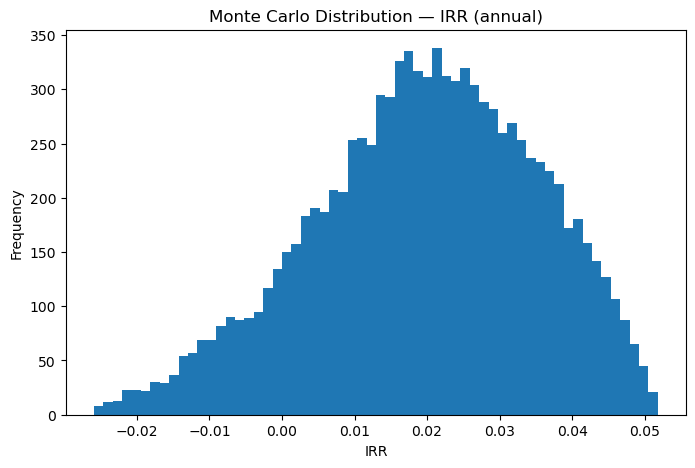

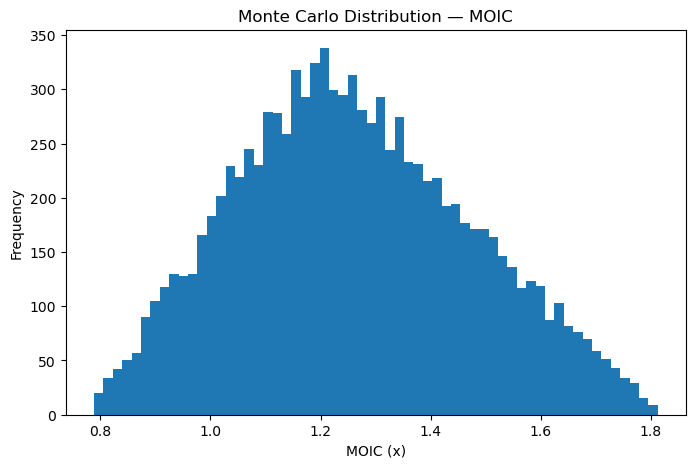

In [9]:
# ============================================================
# Visualizations
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(mc_results["IRR"], bins=60)
plt.title("Monte Carlo Distribution — IRR (annual)")
plt.xlabel("IRR")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(mc_results["MOIC"], bins=60)
plt.title("Monte Carlo Distribution — MOIC")
plt.xlabel("MOIC (x)")
plt.ylabel("Frequency")
plt.show()


In [10]:
# ============================================================
# Export results
# ============================================================

from pathlib import Path

RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")

# robust outputs folder
out_dir = getattr(config, "OUTPUTS_DIR", None)
if out_dir is None:
    out_dir = getattr(config, "OUTPUTS", None)
if out_dir is None:
    out_dir = config.OUTPUTS_DIR  # fallback if exists

out_dir = Path(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

mc_path = out_dir / f"mc_results_exit_multiple_only_{RUN_TS}.csv"
sum_path = out_dir / f"mc_summary_exit_multiple_only_{RUN_TS}.csv"

mc_results.to_csv(mc_path, index=False)
summary_df.to_csv(sum_path, index=False)

print("Saved:", mc_path)
print("Saved:", sum_path)


Saved: C:\Users\Noah\PG3_Royalty_Python_Model\outputs\mc_results_exit_multiple_only_20260223_114756.csv
Saved: C:\Users\Noah\PG3_Royalty_Python_Model\outputs\mc_summary_exit_multiple_only_20260223_114756.csv


In [11]:
mc_results["IRR"].min(), mc_results["IRR"].max(), (mc_results["IRR"].max() - mc_results["IRR"].min())


(np.float64(-0.025908267622016104),
 np.float64(0.05179571812797294),
 np.float64(0.07770398574998905))

In [12]:
test = run_one_path(base, exit_multiple=8.0)
test

test = run_one_path(base, exit_multiple=18.0)
test


{'exit_multiple': 18.0,
 'irr': 0.05196526466520804,
 'moic': np.float64(1.816928169643545)}

In [13]:
run_one_path(base, exit_multiple=8.0), run_one_path(base, exit_multiple=18.0)


({'exit_multiple': 8.0,
  'irr': -0.02774419424995577,
  'moic': np.float64(0.7766902248455055)},
 {'exit_multiple': 18.0,
  'irr': 0.05196526466520804,
  'moic': np.float64(1.816928169643545)})

In [14]:
mc_results["IRR"].min(), mc_results["IRR"].max(), mc_results["IRR"].max() - mc_results["IRR"].min()


(np.float64(-0.025908267622016104),
 np.float64(0.05179571812797294),
 np.float64(0.07770398574998905))

In [15]:
run_one_path(base, 8.0)
run_one_path(base, 12.0)
run_one_path(base, 18.0)


{'exit_multiple': 18.0,
 'irr': 0.05196526466520804,
 'moic': np.float64(1.816928169643545)}

In [16]:
print("IRR mean:", mc_results["IRR"].mean())
print("IRR std:", mc_results["IRR"].std())

print("MOIC mean:", mc_results["MOIC"].mean())
print("MOIC std:", mc_results["MOIC"].std())


IRR mean: 0.019656115089668937
IRR std: 0.015458105423529512
MOIC mean: 1.2601600488783888
MOIC std: 0.21345285824964125


In [17]:
# safety check
print("np:", "np" in globals())
print("mc_results:", "mc_results" in globals())
print("rows:", len(mc_results))

# metrics
print("P(IRR < 0):", (mc_results["IRR"] < 0).mean())
print("IRR pcts:", np.percentile(mc_results["IRR"], [5, 25, 50, 75, 95]))
print("MOIC pcts:", np.percentile(mc_results["MOIC"], [5, 25, 50, 75, 95]))

np: True
mc_results: True
rows: 10000
P(IRR < 0): 0.1141
IRR pcts: [-0.00821902  0.00942596  0.02051389  0.03122745  0.04356077]
MOIC pcts: [0.92243169 1.10302531 1.24619946 1.41057791 1.63675981]


In [18]:
test = run_one_path(base, exit_multiple=12.0)
test


{'exit_multiple': 12.0,
 'irr': 0.016603747693663476,
 'moic': np.float64(1.1927854027647213)}